# 1. Environment Setup

## 1.1 Install and Import libraries

Environment Setup - Install Missing Dependencies

In [1]:
import sys
import subprocess
import importlib

REQUIRED_PACKAGES = {
    "pandas": "pandas",
    "numpy": "numpy",
    "pyarrow": "pyarrow",
    "PIL": "pillow",
    "sklearn": "scikit-learn",
    "tqdm": "tqdm",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "nltk": "nltk",
}

def install_if_missing(module, package):
    try:
        importlib.import_module(module)
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", package]
        )

print("Checking dependencies...\n")

for module, package in REQUIRED_PACKAGES.items():
    install_if_missing(module, package)

print("\n✓ Environment ready")

Checking dependencies...


✓ Environment ready


Runtime Setup

In [35]:
# Core system imports
import os
import re
import html
import time
import warnings
import logging

# NLP Processing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
for resource in ['stopwords', 'wordnet']:
    try:
        nltk.data.find(f'corpora/{resource}')
    except LookupError:
        nltk.download(resource, quiet=True)

# PyTorch & Deep Learning
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Data & ML
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve, auc
)
import joblib

# Transformers & Computer Vision
from transformers import DistilBertTokenizer, DistilBertModel, logging as transformers_logging
from torchvision import models, transforms
from PIL import Image

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Setup device and print environment info
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("=" * 60)
print("ENVIRONMENT SETUP")
print("=" * 60)
import torchvision
import transformers
print(f"PyTorch:      {torch.__version__}")
print(f"TorchVision:  {torchvision.__version__}")
print(f"Transformers: {transformers.__version__}")
print(f"Device:       {DEVICE.upper()}")
if DEVICE == "cuda":
    print(f"GPU:          {torch.cuda.get_device_name(0)}")
print("=" * 60)


# Configure environment
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'
logging.getLogger('transformers').setLevel(logging.ERROR)
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='transformers')
transformers_logging.set_verbosity_error()

ENVIRONMENT SETUP
PyTorch:      2.12.0.dev20260402+cu128
TorchVision:  0.27.0.dev20260402+cu128
Transformers: 5.5.3
Device:       CUDA
GPU:          NVIDIA GeForce RTX 5070 Ti Laptop GPU


## 1.2 Configuration

In [3]:
DATA_PATH = "../data/processed/amazon_reviews_s30.parquet"
MULTIMODAL_DATA = "../data/multimodel/dataset_50k.parquet"

IMAGE_DIR = "../data/multimodel/images"
MODEL_DIR = "../models"
MODEL_SAVE_PATH = "../models/multimodal_model.pt"
MODEL_METADATA_SAVE_PATH = "../models/multimodal_model_metadata.pkl"

SAMPLE_SIZE = 50000
RANDOM_STATE = 42

MAX_TEXT_LENGTH = 256
IMAGE_SIZE = 224

TEXT_IMAGE_PROJ_DIM = 256
METADATA_OUTPUT_DIM = 64

HELPFUL_PERCENTILE = 75

BATCH_SIZE = 16
EPOCHS = 3
LR = 2e-5
TEST_SPLIT_RATIO = 0.3
TEST_VAL_SPLIT_RATIO = 0.5

STEP_SIZE = 1
GAMMA = 0.9

STOP_WORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()
THRESHOLD_PREDS = 0.5

In [4]:
# Text Features
TEXT_COLUMN = "clean_text"

# Image Features
IMAGE_PATH_COLUMN = "image_path"

# Metadata Features
METADATA_COLUMNS = [
    "rating",
    "review_length",
    "is_verified",
    "image_count",
    "has_image",
    "days_since_first_review",
    "product_popularity",
]

# Target
LABEL_COLUMN = "label"

METRICS_MAPPING = {
    "Loss": "loss",
    "Accuracy": "accuracy",
    "Precision": "precision",
    "Recall": "recall",
    "F1-score": "f1",
    "ROC-AUC": "roc_auc"
}

## 1.3 Load and Create Dataset

- Create the label using HELPFUL_PERCENTILE
- Reduce the dataset to 50K for designing purpose of the model

In [5]:
# df = pd.read_parquet(MULTIMODAL_DATA)
# print("Original size:", len(df))

# # Create new dataset for multimodel design
# df = df.sample(SAMPLE_SIZE, random_state=RANDOM_STATE)
# print("Multimodal dataset created with size:", len(df))

# threshold = df["helpful_vote"].quantile(
#     HELPFUL_PERCENTILE / 100
# )
# print(f"Labeling reviews as helpful if helpful_vote >= {threshold:.2f}")

# df["label"] = (df["helpful_vote"] >= threshold).astype(int)
# print(df["label"].value_counts())

# df.to_parquet(MULTIMODAL_DATA)
# print("Multimodel dataset saved to:", MULTIMODAL_DATA)

# 2. Load the Dataset

## 2.1 Loading

In [6]:
if not os.path.exists(MULTIMODAL_DATA):
    print(f"Error: File not found at {MULTIMODAL_DATA}")
    print("Please ensure the file exists before proceeding.")
else:
    df = pd.read_parquet(MULTIMODAL_DATA)
    print("Multimodal dataset loaded with size:", len(df))

Multimodal dataset loaded with size: 50000


## 2.2 Clean the 'review_text' features 

In [7]:
HTML_RE = re.compile(r"<[^>]+>")
URL_RE = re.compile(r"https?://\S+|www\.\S+")
SPECIAL_RE = re.compile(r"[^a-z\s]")

def clean_text(text: str) -> str:
    text = html.unescape(str(text))
    text = HTML_RE.sub(" ", text)
    text = URL_RE.sub(" ", text)
    text = text.lower()
    text = SPECIAL_RE.sub(" ", text)
    tokens = text.split()
    tokens = [LEMMATIZER.lemmatize(w) for w in tokens
              if w not in STOP_WORDS and len(w) > 1]
    return " ".join(tokens)

print("Text Cleaning Examples:")
print("=" * 80)
for i in range(3):
    orig = df["review_text"].iloc[i][:200]
    clean = clean_text(df["review_text"].iloc[i])[:200]
    print(f"\nOriginal : {orig}...")
    print(f"Cleaned  : {clean}...")
    print("-" * 80)

print("\nCleaning all reviews (may take a few minutes on large datasets) ...")
df["clean_text"] = df["review_text"].apply(clean_text)
print("Done.")

empty_after = (df["clean_text"].str.len() == 0).sum()
print(f"Empty reviews after cleaning: {empty_after}")
df.loc[df["clean_text"].str.len() == 0, "clean_text"] = "empty"
print(f"Final dataset size: {len(df):,}")

Text Cleaning Examples:

Original : Best case ever This case is so cute and I constantly get comments....
Cleaned  : best case ever case cute constantly get comment...
--------------------------------------------------------------------------------

Original : It does what it says Installation was amazingly fast, no need to hook it to a computer. I use it as a wifi extender, in a two story, 14 bedroom frat house. And it works great. Picks up wifi signal fro...
Cleaned  : say installation amazingly fast need hook computer use wifi extender two story bedroom frat house work great pick wifi signal front house first floor making strong end second floor download speed beco...
--------------------------------------------------------------------------------

Original : Ok product with one problem Mostly good with easy typing key strokes. The space key is not at the same strength level as the other keys requiring harder hits causing missing spaces that you have to re...
Cleaned  : ok product o

## 2.3 Overview of Dataset

In [8]:
# Validate columns
required_columns = [
    TEXT_COLUMN,
    IMAGE_PATH_COLUMN,
    LABEL_COLUMN,
    *METADATA_COLUMNS
]

missing = [c for c in required_columns if c not in df.columns]
assert len(missing) == 0, f"Missing columns: {missing}"

print("Dataset columns validated successfully.")

Dataset columns validated successfully.


In [9]:
df.iloc[25:30]

,rating,images,parent_asin,timestamp,helpful_vote,review_text,review_length,is_verified,image_count,has_image,days_since_first_review,product_popularity,label,image_url,image_path,clean_text
2309935,5,"[{'attachment_type': 'IMAGE', 'large_image_url...",B08TLSB3WS,2021-03-29 17:52:26.476,14,"Pleasantly surprised! Wow, I was not expecting...",649,1,1,True,8897,11,1,https://images-na.ssl-images-amazon.com/images...,../data/multimodel/images\2309935.jpg,pleasantly surprised wow expecting packaged ni...
838367,5,[],B001OQC0JS,2010-03-30 12:11:27.000,2,So far so good.... I bought this camcorder bec...,583,1,0,False,4879,15,0,NaN,NaN,far good bought camcorder rated consumer repor...
467409,5,[],B000H92BTM,2008-12-15 15:19:38.000,1,"Good Battery Good price, especially if you hav...",108,1,0,False,4409,45,0,NaN,NaN,good battery good price especially dock need p...
356196,5,[],B0BRQGBJ64,2022-09-08 17:44:47.628,16,Perfect for my digital art I decided to finall...,344,1,0,False,9425,357,1,NaN,NaN,perfect digital art decided finally upgrade ye...
2548792,1,[],B08N6HJ3FB,2010-12-15 13:19:55.000,5,"Terrible cord, short life I bought these headp...",1202,0,0,False,5139,308,1,NaN,NaN,terrible cord short life bought headphone desp...


In [10]:
df.dtypes

rating                               int8
images                             object
parent_asin                      category
timestamp                  datetime64[ms]
helpful_vote                        int32
review_text                           str
review_length                       int32
is_verified                          int8
image_count                         int16
has_image                            bool
days_since_first_review             int32
product_popularity                  int32
label                               int64
image_url                             str
image_path                            str
clean_text                            str
dtype: object

# 3. Create Split

In [11]:
from sklearn.model_selection import train_test_split

train_df, val_test_df = train_test_split(
    df,
    test_size=TEST_SPLIT_RATIO,
    stratify=df[LABEL_COLUMN],
    random_state=RANDOM_STATE
)


val_df, test_df = train_test_split(
    val_test_df,
    test_size=TEST_VAL_SPLIT_RATIO,
    stratify=val_test_df[LABEL_COLUMN],
    random_state=RANDOM_STATE
)


print(f"Train size: {len(train_df)}, Validation size: {len(val_df)}, Test size: {len(test_df)}")

Train size: 35000, Validation size: 7500, Test size: 7500


## 3.1 Scale the features in METADATA_COLUMNS.

METADATA_COLUMNS have numeric features

Why is it done after splitting? \
Data Leakage Prevention: If you fit the scaler on the entire dataset before splitting, the test set's statistics (mean/std) influence the scaler's parameters. This leaks test information into training, artificially inflating your model's performance metrics.

Real-world Validity: In production, you won't have test data available, so you can only fit the scaler on training data.

In [12]:
scaler = StandardScaler()

# Fit only on training metadata
scaler.fit(train_df[METADATA_COLUMNS])

# Transform both train, validation, and test metadata
train_df[METADATA_COLUMNS] = scaler.transform(train_df[METADATA_COLUMNS])
val_df[METADATA_COLUMNS] = scaler.transform(val_df[METADATA_COLUMNS])
test_df[METADATA_COLUMNS] = scaler.transform(test_df[METADATA_COLUMNS])

# Save scaler for inference
joblib.dump(scaler, MODEL_METADATA_SAVE_PATH)
print(f"Scaler saved to {MODEL_METADATA_SAVE_PATH}")

Scaler saved to ../models/multimodal_model_metadata.pkl


# 4. Build Model Components
INITIALIZE PREPROCESSORS

## 4.1 Text Tokenizer

In [13]:
tokenizer = DistilBertTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

## 4.2 Image Transform Pipeline

In [14]:
image_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# 5. Create Multimodal Dataset Class

In [15]:
class MultimodalDataset(Dataset):
    def __init__(self, dataframe, tokenizer, image_transform):
        self.df = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.image_transform = image_transform

        self.text_col = TEXT_COLUMN
        self.image_col = IMAGE_PATH_COLUMN
        self.metadata_cols = METADATA_COLUMNS
        self.label_col = LABEL_COLUMN

        self.max_text_len = MAX_TEXT_LENGTH

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ------ Text Processing ------
        text = str(row[self.text_col])
        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_text_len,
            return_tensors="pt"
        )

        input_ids = encoding["input_ids"].squeeze(0)
        attention_mask = encoding["attention_mask"].squeeze(0)

        # ------ Image Processing ------
        image_path = row[self.image_col]

        if isinstance(image_path, str) and os.path.exists(image_path):
            try:
                image = Image.open(image_path).convert("RGB")
                image = self.image_transform(image)
            except Exception:
                image = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
        else:
            image = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)

        # ------ Metadata Processing ------
        metadata = torch.tensor(
            row[self.metadata_cols].values.astype(np.float32)
        )

        # ------ Label ------
        label = torch.tensor(row[self.label_col], dtype=torch.float32)

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "image": image,
            "metadata": metadata,
            "label": label
        }

# 6. Create DataLoaders

In [16]:
train_dataset = MultimodalDataset(
    dataframe = train_df,
    tokenizer = tokenizer,
    image_transform = image_transform
)


val_dataset = MultimodalDataset(
    dataframe = val_df,
    tokenizer = tokenizer,
    image_transform = image_transform
)

test_dataset = MultimodalDataset(
    dataframe = test_df,
    tokenizer = tokenizer,
    image_transform = image_transform
)

In [17]:
# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# 7. Build Model Components

In [18]:
class MultimodalModel(nn.Module):

    def __init__(self):
        super().__init__()

        # ------ Text Branch -----
        self.text_encoder = DistilBertModel.from_pretrained(
            "distilbert-base-uncased"
        )
        self.text_proj = nn.Linear(768, TEXT_IMAGE_PROJ_DIM)

        # ------ Image Branch -----
        self.image_encoder = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.DEFAULT
        )
        self.image_encoder.classifier = nn.Sequential()
        self.image_proj = nn.Linear(1280, TEXT_IMAGE_PROJ_DIM)

        # ------ Metadata Branch -----
        self.metadata_encoder = nn.Sequential(
            nn.Linear(len(METADATA_COLUMNS), METADATA_OUTPUT_DIM),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # ------ Fusion + Classifier -----
        self.classifier = nn.Sequential(
            nn.Linear(TEXT_IMAGE_PROJ_DIM * 2 + METADATA_OUTPUT_DIM, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )


    def forward(self, input_ids, attention_mask, image, metadata):
        # ------ Text Branch -----
        text_output = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        text_feat = text_output.last_hidden_state[:, 0]
        text_feat = self.text_proj(text_feat)

        # ------ Image Branch -----
        image_feat = self.image_encoder(image)
        image_feat = self.image_proj(image_feat)

        # ------ Metadata Branch -----
        metadata_feat = self.metadata_encoder(metadata)

        # ------ Fusion -----
        fused = torch.cat(
            [text_feat, image_feat, metadata_feat],
            dim=1
        )

        logits = self.classifier(fused)

        return logits.squeeze(1)

## 7.1 Setup

In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultimodalModel().to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=STEP_SIZE,
    gamma=GAMMA
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

## 7.2 Function to Compute Metrics

In [20]:
def compute_metrics(targets, preds, probs):
    """Compute all metrics from predictions"""
    return {
        "Accuracy": accuracy_score(targets, preds),
        "Precision": precision_score(targets, preds),
        "Recall": recall_score(targets, preds),
        "F1-score": f1_score(targets, preds),
        "ROC-AUC": roc_auc_score(targets, probs),
        "Confusion Matrix": confusion_matrix(targets, preds)
    }


# 8. Training Loop

In [21]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0
    
    probs = []
    preds = []
    targets = []
    
    start_time = time.time()
    total_inference_time = 0
    total_samples = 0

    for batch in loader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        image = batch["image"].to(device)
        metadata = batch["metadata"].to(device)
        labels = batch["label"].to(device)

        infer_start = time.time()
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            image=image,
            metadata=metadata
        )

        infer_end = time.time()
        total_inference_time += (infer_end - infer_start)
        total_samples += labels.size(0)
        
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        
        # Collect predictions and targets for metrics
        probabilities = torch.sigmoid(outputs)
        predictions = probabilities > THRESHOLD_PREDS
        
        probs.extend(probabilities.detach().cpu().numpy())
        preds.extend(predictions.detach().cpu().numpy())
        targets.extend(labels.cpu().numpy())

    total_train_time = time.time() - start_time
    
    # ------- Metrics Calculation -------
    metrics = compute_metrics(targets, preds, probs)
    avg_loss = total_loss / len(loader)
    latency_per_sample = total_inference_time / total_samples

    results = {
        **metrics,  # Unpack all metrics from compute_metrics
        "Loss": avg_loss,
        "Training Time (sec)": total_train_time,
        "Inference Latency (sec/sample)": latency_per_sample
    }
    return results

# 9. Validation Loop

In [22]:
def evaluate(model, loader, device=device):
    model.eval()

    probs = []
    preds = []
    targets = []

    start_time = time.time()

    total_inference_time = 0
    total_samples = 0
    total_loss = 0

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            image = batch["image"].to(device)
            metadata = batch["metadata"].to(device)
            labels = batch["label"].to(device)

            # Inference time measurement
            infer_start = time.time()

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                image=image,
                metadata=metadata
            )

            infer_end = time.time()
            total_inference_time += (infer_end - infer_start)
            total_samples += labels.size(0)

            loss = criterion(outputs, labels)  # Add this
            total_loss += loss.item()

            probabilities = torch.sigmoid(outputs)
            predictions = probabilities > 0.5

            probs.extend(probabilities.cpu().numpy())
            preds.extend(predictions.cpu().numpy())
            targets.extend(labels.cpu().numpy())

    total_eval_time = time.time() - start_time

    # ------- Metrics Calculation -------
    metrics = compute_metrics(targets, preds, probs)
    avg_loss = total_loss / len(loader)
    latency_per_sample = total_inference_time / total_samples

    results = {
        **metrics,  # Unpack all metrics from compute_metrics
        "Loss": avg_loss,
        "Evaluation Time (sec)": total_eval_time,
        "Inference Latency (sec/sample)": latency_per_sample,

        # Raw predictions stored separately
        "probs": np.array(probs).flatten(),
        "preds": np.array(preds).flatten(),
        "targets": np.array(targets).flatten()
    }
    return results

# 10. Model Checkpoints

In [23]:
best_acc = 0

# Initialize history to track metrics across epochs
history = {
    "epochs": [],
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],       
    "val_accuracy": [],
    "train_precision": [],
    "val_precision": [],
    "train_recall": [],
    "val_recall": [],
    "train_f1": [],
    "val_f1": [],
    "train_roc_auc": [],
    "val_roc_auc": []
}

for epoch in range(EPOCHS):
    train_results = train_epoch(model, train_loader)
    val_results = evaluate(model, val_loader)

    # Store in history in one pass
    history["epochs"].append(epoch + 1)
    for metric_key, short_key in METRICS_MAPPING.items():
        history[f"train_{short_key}"].append(train_results[metric_key])
        history[f"val_{short_key}"].append(val_results[metric_key])

    scheduler.step()

    # Print summary
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_results['Loss']:.4f} | Acc: {train_results['Accuracy']:.4f} | "
          f"F1: {train_results['F1-score']:.4f} | Prec: {train_results['Precision']:.4f} | "
          f"Rec: {train_results['Recall']:.4f} | Time: {train_results['Training Time (sec)']:.2f}s")
    print(f"Val   Loss: {val_results['Loss']:.4f} | Acc: {val_results['Accuracy']:.4f} | "
          f"F1: {val_results['F1-score']:.4f} | Prec: {val_results['Precision']:.4f} | "
          f"Rec: {val_results['Recall']:.4f} | Time: {val_results['Evaluation Time (sec)']:.2f}s")
    
    if val_results['Accuracy'] > best_acc:
        best_acc = val_results['Accuracy']
        os.makedirs(MODEL_DIR, exist_ok=True) # Create model directory if it doesn't exist
        torch.save(model.state_dict(), MODEL_SAVE_PATH)

Epoch 1/3
Train Loss: 0.5586 | Acc: 0.7201 | F1: 0.3210 | Prec: 0.5769 | Rec: 0.2223 | Time: 557.37s
Val   Loss: 0.7873 | Acc: 0.7235 | F1: 0.3200 | Prec: 0.5958 | Rec: 0.2187 | Time: 63.23s
Epoch 2/3
Train Loss: 0.5412 | Acc: 0.7313 | F1: 0.3737 | Prec: 0.6093 | Rec: 0.2695 | Time: 557.23s
Val   Loss: 0.5594 | Acc: 0.7180 | F1: 0.3175 | Prec: 0.5668 | Rec: 0.2205 | Time: 65.34s
Epoch 3/3
Train Loss: 0.5039 | Acc: 0.7545 | F1: 0.4979 | Prec: 0.6360 | Rec: 0.4090 | Time: 1171.97s
Val   Loss: 0.6314 | Acc: 0.7109 | F1: 0.3574 | Prec: 0.5276 | Rec: 0.2703 | Time: 50.82s


## Visualization of the metrics

1. Confusion Matrix
2. ROC Curve
3. Testing Vs Training/Validation Comparision (Summary table)

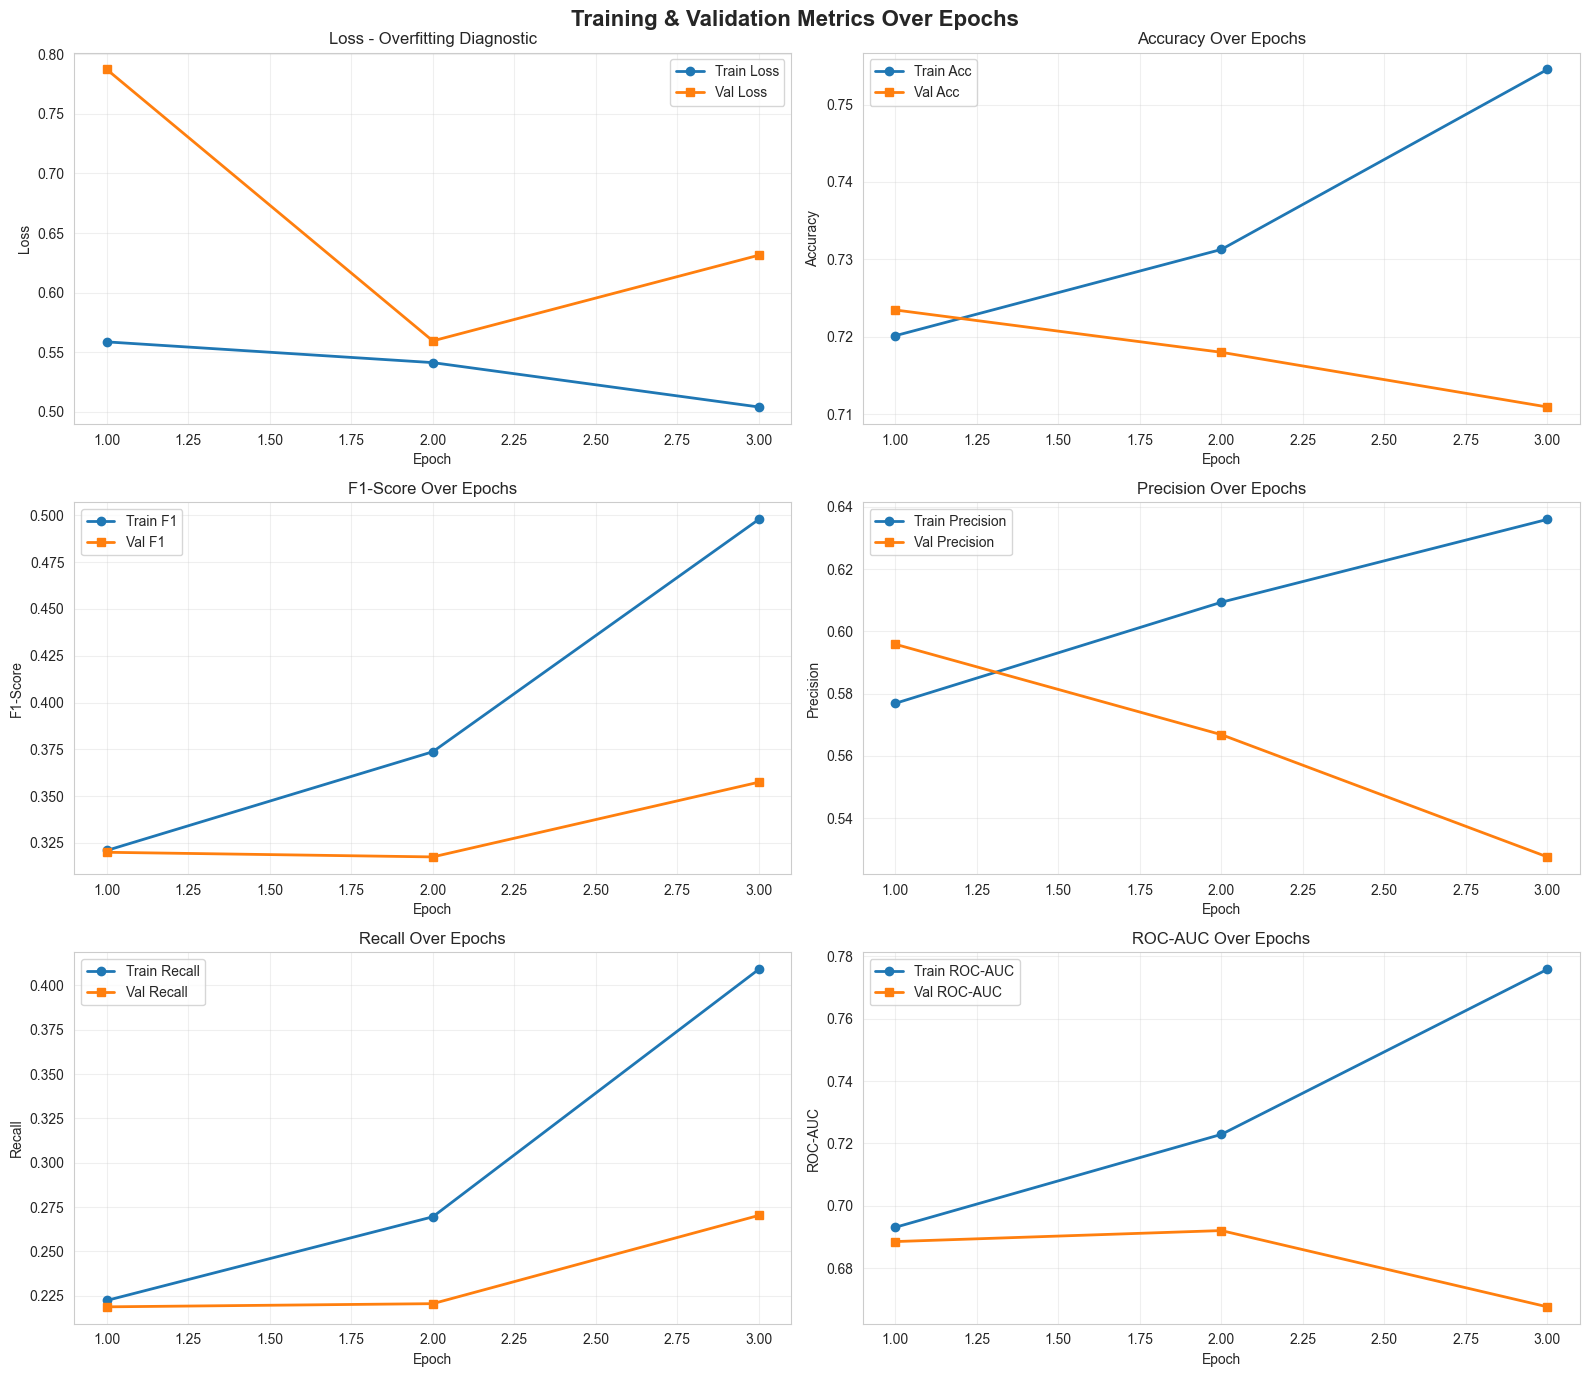

In [24]:
# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Create subplots for comprehensive training analysis
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('Training & Validation Metrics Over Epochs', fontsize=16, fontweight='bold')

# 1. Loss Curve
axes[0, 0].plot(history["epochs"], history["train_loss"], marker='o', label='Train Loss', linewidth=2)
axes[0, 0].plot(history["epochs"], history["val_loss"], marker='s', label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss - Overfitting Diagnostic')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Accuracy Curve
axes[0, 1].plot(history["epochs"], history["train_accuracy"], marker='o', label='Train Acc', linewidth=2)
axes[0, 1].plot(history["epochs"], history["val_accuracy"], marker='s', label='Val Acc', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy Over Epochs')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. F1-Score Curve
axes[1, 0].plot(history["epochs"], history["train_f1"], marker='o', label='Train F1', linewidth=2)
axes[1, 0].plot(history["epochs"], history["val_f1"], marker='s', label='Val F1', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('F1-Score')
axes[1, 0].set_title('F1-Score Over Epochs')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Precision Curve
axes[1, 1].plot(history["epochs"], history["train_precision"], marker='o', label='Train Precision', linewidth=2)
axes[1, 1].plot(history["epochs"], history["val_precision"], marker='s', label='Val Precision', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].set_title('Precision Over Epochs')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 5. Recall Curve
axes[2, 0].plot(history["epochs"], history["train_recall"], marker='o', label='Train Recall', linewidth=2)
axes[2, 0].plot(history["epochs"], history["val_recall"], marker='s', label='Val Recall', linewidth=2)
axes[2, 0].set_xlabel('Epoch')
axes[2, 0].set_ylabel('Recall')
axes[2, 0].set_title('Recall Over Epochs')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# 6. ROC-AUC Curve
axes[2, 1].plot(history["epochs"], history["train_roc_auc"], marker='o', label='Train ROC-AUC', linewidth=2)
axes[2, 1].plot(history["epochs"], history["val_roc_auc"], marker='s', label='Val ROC-AUC', linewidth=2)
axes[2, 1].set_xlabel('Epoch')
axes[2, 1].set_ylabel('ROC-AUC')
axes[2, 1].set_title('ROC-AUC Over Epochs')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
# ------- OVERFITTING DIAGNOSTICS -------
print("\n" + "="*80)
print("OVERFITTING DIAGNOSTICS")
print("="*80)

train_loss_gap = history["train_loss"][-1] - history["val_loss"][-1]
train_acc_gap = history["train_accuracy"][-1] - history["val_accuracy"][-1]
train_loss_improvement = history["train_loss"][0] - history["train_loss"][-1]
val_loss_improvement = history["val_loss"][0] - history["val_loss"][-1]

print(f"\nFinal Epoch Statistics:")
print(f"  Train Loss: {history['train_loss'][-1]:.4f} → Val Loss: {history['val_loss'][-1]:.4f}")
print(f"  Train Acc:  {history['train_accuracy'][-1]:.4f} → Val Acc:  {history['val_accuracy'][-1]:.4f}")
print(f"  Train F1:   {history['train_f1'][-1]:.4f} → Val F1:   {history['val_f1'][-1]:.4f}")

print(f"\nGap Analysis (Train - Val):")
print(f"  Loss Gap: {train_loss_gap:+.4f}")
print(f"  Acc Gap:  {train_acc_gap:+.4f}")

print(f"\nImprovement from Epoch 1 to Final:")
print(f"  Train Loss: {train_loss_improvement:+.4f}")
print(f"  Val Loss:   {val_loss_improvement:+.4f}")

if train_loss_gap > 0.1 or train_acc_gap > 0.1:
    print(f"\n⚠️  OVERFITTING DETECTED: Large gap between train and validation metrics")
else:
    print(f"\n✅ GOOD GENERALIZATION: Train and validation metrics are well-aligned")


OVERFITTING DIAGNOSTICS

Final Epoch Statistics:
  Train Loss: 0.5039 → Val Loss: 0.6314
  Train Acc:  0.7545 → Val Acc:  0.7109
  Train F1:   0.4979 → Val F1:   0.3574

Gap Analysis (Train - Val):
  Loss Gap: -0.1274
  Acc Gap:  +0.0436

Improvement from Epoch 1 to Final:
  Train Loss: +0.0547
  Val Loss:   +0.1560

✅ GOOD GENERALIZATION: Train and validation metrics are well-aligned


# 11. Testing / Final Evaluation

In [26]:
# Check if the file exists before loading
if not os.path.exists(MODEL_SAVE_PATH):
    print(f"Error: Model file not found at {MODEL_SAVE_PATH}")
    print("Please ensure the model was saved correctly during training.")
else:
    model.load_state_dict(torch.load(MODEL_SAVE_PATH))

test_results = evaluate(model, test_loader)
test_acc = test_results["Accuracy"]

print(f"Final Test Accuracy: {test_acc:.4f}")

Final Test Accuracy: 0.7308


## Visualization

In [27]:
all_probs = test_results["probs"]
all_preds = test_results["preds"]
all_targets = test_results["targets"]

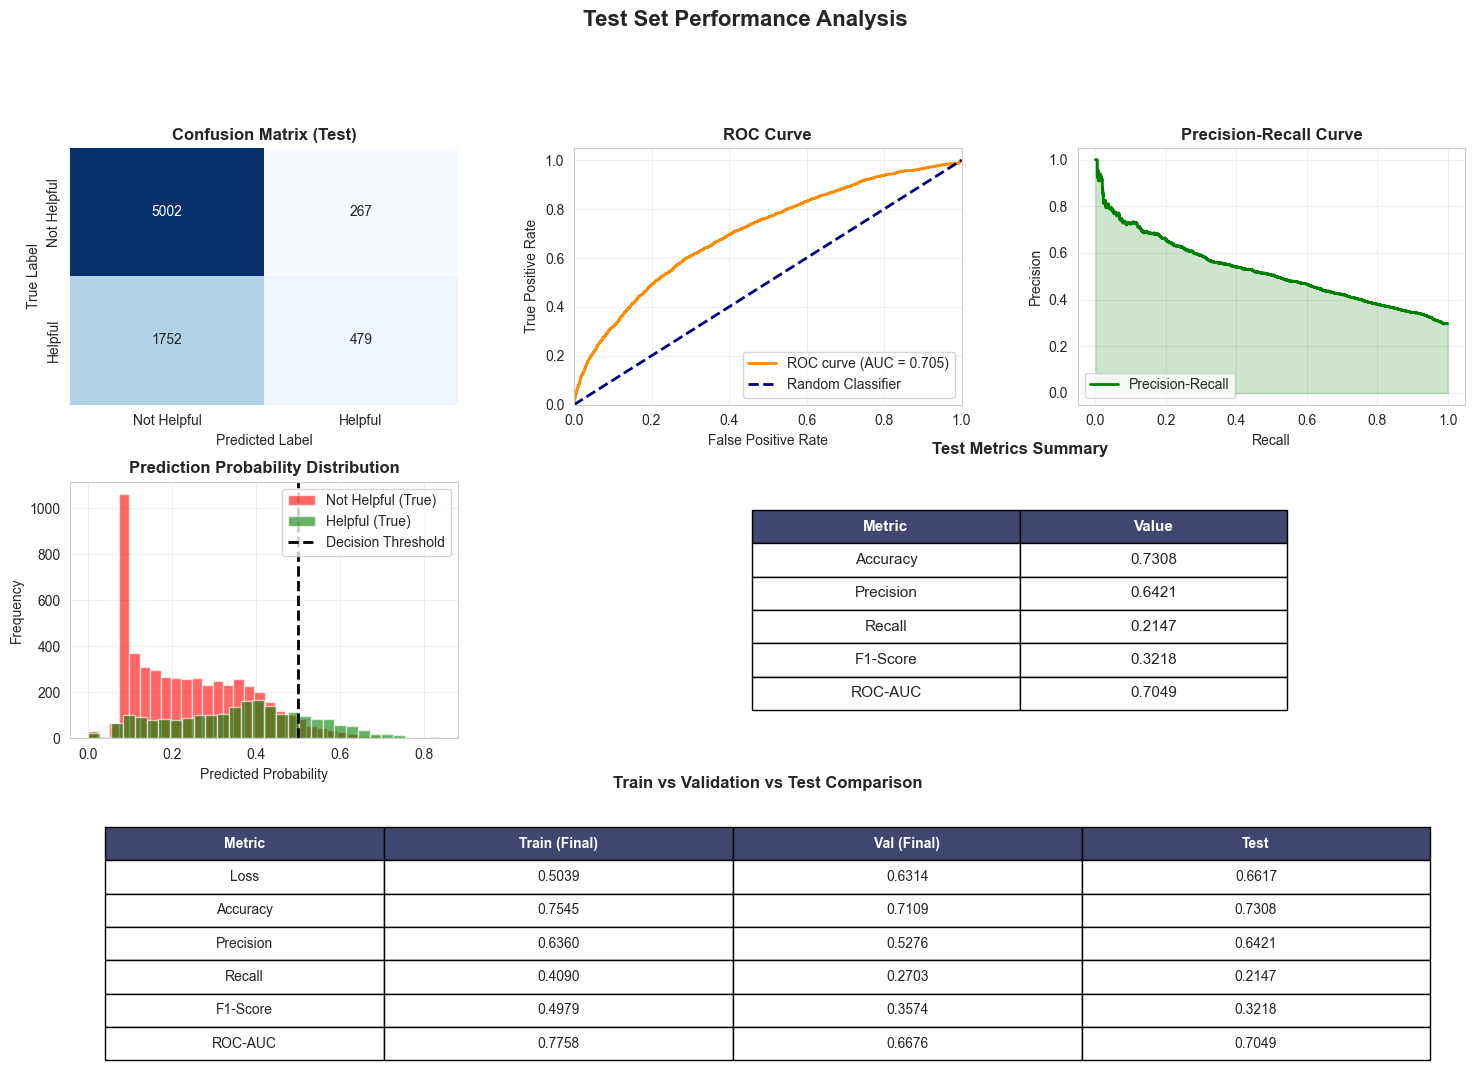


TEST SET PERFORMANCE SUMMARY
Test Accuracy:  0.7308
Test Precision: 0.6421
Test Recall:    0.2147
Test F1-Score:  0.3218
Test ROC-AUC:   0.7049


In [28]:
# Create comprehensive visualization
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Confusion Matrix
ax1 = fig.add_subplot(gs[0, 0])
cm = test_results["Confusion Matrix"]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=False)
ax1.set_title('Confusion Matrix (Test)', fontweight='bold')
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')
ax1.set_xticklabels(['Not Helpful', 'Helpful'])
ax1.set_yticklabels(['Not Helpful', 'Helpful'])

# 2. ROC Curve
ax2 = fig.add_subplot(gs[0, 1])
fpr, tpr, _ = roc_curve(all_targets, all_probs)
roc_auc = auc(fpr, tpr)
ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve', fontweight='bold')
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)

# 3. Precision-Recall Curve
ax3 = fig.add_subplot(gs[0, 2])
precision, recall, _ = precision_recall_curve(all_targets, all_probs)
ax3.plot(recall, precision, color='green', lw=2, label='Precision-Recall')
ax3.fill_between(recall, precision, alpha=0.2, color='green')
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.set_title('Precision-Recall Curve', fontweight='bold')
ax3.legend(loc="lower left")
ax3.grid(True, alpha=0.3)

# 4. Prediction Distribution
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(all_probs[all_targets == 0], bins=30, alpha=0.6, label='Not Helpful (True)', color='red')
ax4.hist(all_probs[all_targets == 1], bins=30, alpha=0.6, label='Helpful (True)', color='green')
ax4.set_xlabel('Predicted Probability')
ax4.set_ylabel('Frequency')
ax4.set_title('Prediction Probability Distribution', fontweight='bold')
ax4.axvline(0.5, color='black', linestyle='--', linewidth=2, label='Decision Threshold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Metrics Comparison Table
ax5 = fig.add_subplot(gs[1, 1:])
ax5.axis('tight')
ax5.axis('off')

metrics_data = [
    ['Metric', 'Value'],
    ['Accuracy', f"{test_results['Accuracy']:.4f}"],
    ['Precision', f"{test_results['Precision']:.4f}"],
    ['Recall', f"{test_results['Recall']:.4f}"],
    ['F1-Score', f"{test_results['F1-score']:.4f}"],
    ['ROC-AUC', f"{test_results['ROC-AUC']:.4f}"]
]

table = ax5.table(cellText=metrics_data, cellLoc='center', loc='center', 
                  colWidths=[0.3, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)

# Style header row
for i in range(2):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

ax5.set_title('Test Metrics Summary', fontweight='bold', pad=20)

# 6. Train vs Val vs Test Comparison
ax6 = fig.add_subplot(gs[2, :])
ax6.axis('tight')
ax6.axis('off')

comparison_data = [
    ['Metric', 'Train (Final)', 'Val (Final)', 'Test'],
    ['Loss', f"{history['train_loss'][-1]:.4f}", f"{history['val_loss'][-1]:.4f}", 
     f"{test_results['Loss']:.4f}"],
    ['Accuracy', f"{history['train_accuracy'][-1]:.4f}", f"{history['val_accuracy'][-1]:.4f}", 
     f"{test_results['Accuracy']:.4f}"],
    ['Precision', f"{history['train_precision'][-1]:.4f}", f"{history['val_precision'][-1]:.4f}", 
     f"{test_results['Precision']:.4f}"],
    ['Recall', f"{history['train_recall'][-1]:.4f}", f"{history['val_recall'][-1]:.4f}", 
     f"{test_results['Recall']:.4f}"],
    ['F1-Score', f"{history['train_f1'][-1]:.4f}", f"{history['val_f1'][-1]:.4f}", 
     f"{test_results['F1-score']:.4f}"],
    ['ROC-AUC', f"{history['train_roc_auc'][-1]:.4f}", f"{history['val_roc_auc'][-1]:.4f}", 
     f"{test_results['ROC-AUC']:.4f}"]
]

comparison_table = ax6.table(cellText=comparison_data, cellLoc='center', loc='center',
                             colWidths=[0.2, 0.25, 0.25, 0.25])
comparison_table.auto_set_font_size(False)
comparison_table.set_fontsize(10)
comparison_table.scale(1, 2)

# Style header row
for i in range(4):
    comparison_table[(0, i)].set_facecolor('#40466e')
    comparison_table[(0, i)].set_text_props(weight='bold', color='white')

ax6.set_title('Train vs Validation vs Test Comparison', fontweight='bold', pad=20)

plt.suptitle('Test Set Performance Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.show()

# Print summary
print("\n" + "="*80)
print("TEST SET PERFORMANCE SUMMARY")
print("="*80)
print(f"Test Accuracy:  {test_results['Accuracy']:.4f}")
print(f"Test Precision: {test_results['Precision']:.4f}")
print(f"Test Recall:    {test_results['Recall']:.4f}")
print(f"Test F1-Score:  {test_results['F1-score']:.4f}")
print(f"Test ROC-AUC:   {test_results['ROC-AUC']:.4f}")

# 12. Error Analysis & Modality Breakdown

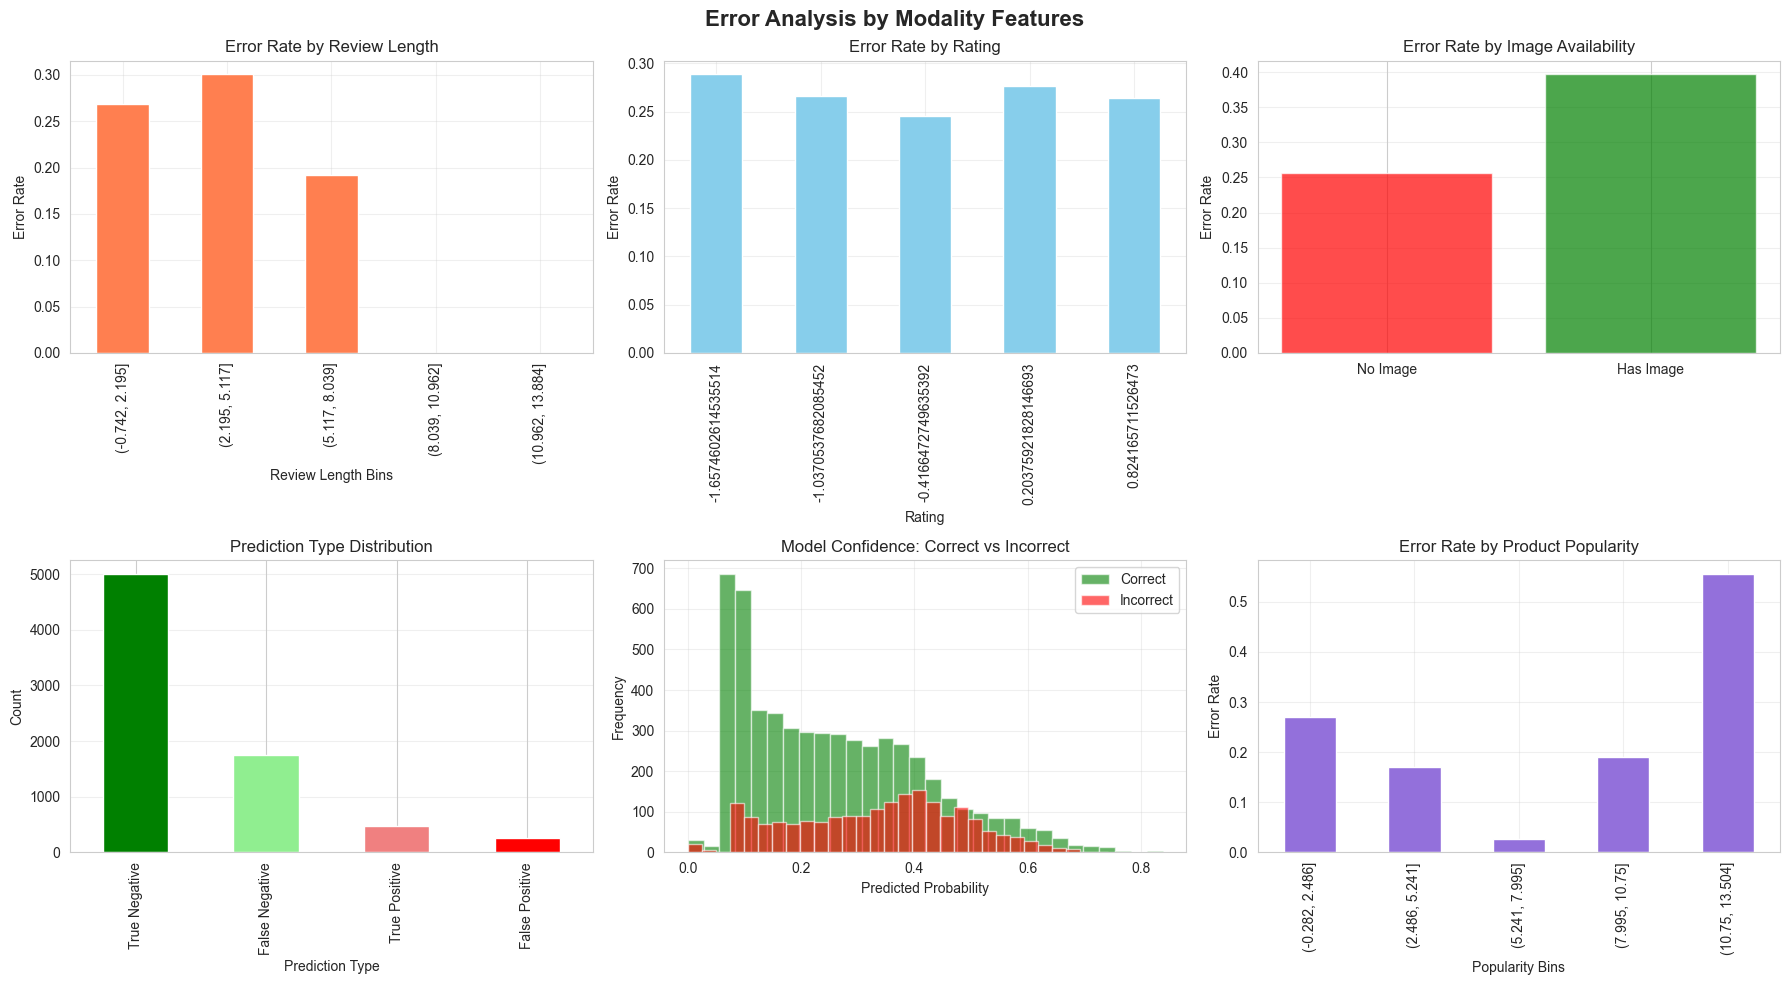

In [29]:
# Create comprehensive error analysis DataFrame
test_df_copy = test_df.reset_index(drop=True).copy()
test_df_copy['predicted_prob'] = all_probs
test_df_copy['predicted_label'] = all_preds
test_df_copy['true_label'] = all_targets
test_df_copy['is_correct'] = (test_df_copy['predicted_label'] == test_df_copy['true_label']).astype(int)
test_df_copy['error_type'] = test_df_copy.apply(
    lambda x: 'True Positive' if (x['predicted_label']==1 and x['true_label']==1) 
    else 'True Negative' if (x['predicted_label']==0 and x['true_label']==0)
    else 'False Positive' if (x['predicted_label']==1 and x['true_label']==0)
    else 'False Negative', axis=1
)

# Create visualization for error analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Error Analysis by Modality Features', fontsize=16, fontweight='bold')

# 1. Error rate by text length
ax = axes[0, 0]
text_length_bins = pd.cut(test_df_copy['review_length'], bins=5)
error_by_text = test_df_copy.groupby(text_length_bins)['is_correct'].apply(lambda x: 1 - x.mean())
error_by_text.plot(kind='bar', ax=ax, color='coral')
ax.set_title('Error Rate by Review Length')
ax.set_ylabel('Error Rate')
ax.set_xlabel('Review Length Bins')
ax.grid(True, alpha=0.3)

# 2. Error rate by rating
ax = axes[0, 1]
error_by_rating = test_df_copy.groupby('rating')['is_correct'].apply(lambda x: 1 - x.mean())
error_by_rating.plot(kind='bar', ax=ax, color='skyblue')
ax.set_title('Error Rate by Rating')
ax.set_ylabel('Error Rate')
ax.set_xlabel('Rating')
ax.grid(True, alpha=0.3)

# 3. Error rate by image availability
ax = axes[0, 2]
error_by_image = test_df_copy.groupby('has_image')['is_correct'].apply(lambda x: 1 - x.mean())
image_labels = ['No Image', 'Has Image']
ax.bar(image_labels, error_by_image.values, color=['red', 'green'], alpha=0.7)
ax.set_title('Error Rate by Image Availability')
ax.set_ylabel('Error Rate')
ax.grid(True, alpha=0.3, axis='y')

# 4. Error distribution by type
ax = axes[1, 0]
error_counts = test_df_copy['error_type'].value_counts()
colors = ['green', 'lightgreen', 'lightcoral', 'red']
error_counts.plot(kind='bar', ax=ax, color=colors)
ax.set_title('Prediction Type Distribution')
ax.set_ylabel('Count')
ax.set_xlabel('Prediction Type')
ax.grid(True, alpha=0.3, axis='y')

# 5. Confidence by correctness
ax = axes[1, 1]
correct_probs = test_df_copy[test_df_copy['is_correct'] == 1]['predicted_prob']
incorrect_probs = test_df_copy[test_df_copy['is_correct'] == 0]['predicted_prob']
ax.hist(correct_probs, bins=30, alpha=0.6, label='Correct', color='green')
ax.hist(incorrect_probs, bins=30, alpha=0.6, label='Incorrect', color='red')
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Frequency')
ax.set_title('Model Confidence: Correct vs Incorrect')
ax.legend()
ax.grid(True, alpha=0.3)

# 6. Error analysis by product popularity
ax = axes[1, 2]
pop_bins = pd.cut(test_df_copy['product_popularity'], bins=5)
error_by_pop = test_df_copy.groupby(pop_bins)['is_correct'].apply(lambda x: 1 - x.mean())
error_by_pop.plot(kind='bar', ax=ax, color='mediumpurple')
ax.set_title('Error Rate by Product Popularity')
ax.set_ylabel('Error Rate')
ax.set_xlabel('Popularity Bins')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 13. Inference Pipeline

Model Persistence & Serialization

In [32]:
def predict(model, text, image_path, metadata_values, device=None):
    """Generate prediction for a single instance."""
    import joblib
    
    # Resolve device
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    model.eval()
    
    # Load scaler for metadata normalization
    if not os.path.exists(MODEL_METADATA_SAVE_PATH):
        raise FileNotFoundError(f"Scaler not found at {MODEL_METADATA_SAVE_PATH}. Please train the model first.")
    scaler = joblib.load(MODEL_METADATA_SAVE_PATH)
    
    # Text - create tensor and move to device immediately
    encoding = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=MAX_TEXT_LENGTH,
        return_tensors="pt"
    )
    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)
    
    # Image - handle missing/corrupted files gracefully
    if not os.path.exists(image_path):
        print(f"Warning: Image not found at {image_path}, using placeholder")
        image = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
    else:
        try:
            image = Image.open(image_path).convert("RGB")
            image = image_transform(image).unsqueeze(0).to(device)
        except Exception as e:
            print(f"Warning: Could not load image: {e}, using placeholder")
            image = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
    
    # Metadata - validate, scale, and move to device
    if len(metadata_values) != len(METADATA_COLUMNS):
        raise ValueError(f"Expected {len(METADATA_COLUMNS)} metadata values, got {len(metadata_values)}")
    
    # Scale metadata using trained scaler
    metadata_scaled = scaler.transform([metadata_values])[0]
    metadata = torch.tensor(metadata_scaled, dtype=torch.float32).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            image=image,
            metadata=metadata
        )
        prob = torch.sigmoid(output).item()
    
    return prob

# 14. Threshold Optimization Analysis

In [33]:
# Test multiple thresholds
thresholds = np.arange(0.3, 0.75, 0.05)
threshold_results = []

for thresh in thresholds:
    preds_at_thresh = (all_probs >= thresh).astype(int)

    acc = accuracy_score(all_targets, preds_at_thresh)
    prec = precision_score(all_targets, preds_at_thresh, zero_division=0)
    rec = recall_score(all_targets, preds_at_thresh, zero_division=0)
    f1 = f1_score(all_targets, preds_at_thresh, zero_division=0)

    fbeta_05 = fbeta_score(all_targets, preds_at_thresh, beta=0.5, zero_division=0)
    fbeta_20 = fbeta_score(all_targets, preds_at_thresh, beta=2.0, zero_division=0)

    roc_auc_val = roc_auc_score(all_targets, all_probs)

    threshold_results.append({
        'Threshold': thresh,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'F-Beta(0.5)': fbeta_05,
        'F-Beta(2.0)': fbeta_20,
        'ROC-AUC': roc_auc_val
    })

threshold_df = pd.DataFrame(threshold_results)

print("\n" + "="*80)
print("THRESHOLD PERFORMANCE COMPARISON")
print("="*80)
print(threshold_df.to_string(index=False))


THRESHOLD PERFORMANCE COMPARISON
 Threshold  Accuracy  Precision   Recall  F1-Score  F-Beta(0.5)  F-Beta(2.0)  ROC-AUC
      0.30  0.652800   0.442492 0.643209  0.524297     0.471946     0.589710 0.704871
      0.35  0.689867   0.481277 0.547288  0.512164     0.493174     0.532676 0.704871
      0.40  0.717600   0.531653 0.425370  0.472610     0.506349     0.443085 0.704871
      0.45  0.729067   0.585261 0.306141  0.402001     0.494999     0.338420 0.704871
      0.50  0.730800   0.642091 0.214702  0.321800     0.459252     0.247673 0.704871
      0.55  0.726000   0.689655 0.143433  0.237477     0.391485     0.170430 0.704871
      0.60  0.717067   0.728033 0.077992  0.140891     0.272984     0.094947 0.704871
      0.65  0.711067   0.801887 0.038100  0.072743     0.160075     0.047065 0.704871
      0.70  0.707200   0.926829 0.017033  0.033451     0.079332     0.021194 0.704871
